In [1]:
import sys
from pathlib import Path

import numpy as np

sys.path.append(str(Path().resolve().parent))

import src.load_data as ld
import src.visualization as vsl

/home/tbm-demi/miniconda3/envs/finance_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cac cot can de doc
columns = ['LIMIT_BAL', 'AGE', 'IS_DEFAULT']


df= ld.load_parquet(file= "UCI_Credit_Card_cleaned", collumns= columns)
df_raw= ld.load_parquet(file= "UCI_Credit_Card")

2026-04-03 15:30:27 - INFO - Execution time: 0.0289
2026-04-03 15:30:27 - INFO - Execution time: 0.0099


In [3]:
df.groupby('IS_DEFAULT')['LIMIT_BAL'].describe()

,count,mean,std,min,25%,50%,75%,max
IS_DEFAULT,,,,,,,,
0,23364.0,178099.726074,131628.359660,10000.0,70000.0,150000.0,250000.0,1000000.0
1,6636.0,130109.656420,115378.540571,10000.0,50000.0,90000.0,200000.0,740000.0


/home/tbm-demi/Documents/Code/Finance/src/visualization.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation= rotation)
2026-04-03 15:30:27 - INFO - Generated Distribution plot for: LIMIT_BAL_LOG


<Axes: title={'center': 'Distribution of LIMIT_BAL_LOG'}, xlabel='Limit Bal Log', ylabel='Frequency'>

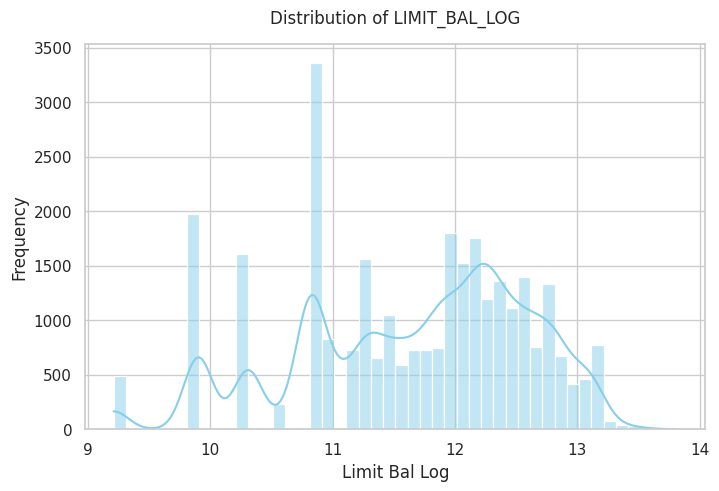

In [4]:
# Boxplot hạn mức tín dụng và nợ xấu
df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])

vsl.plot_distribution(df= df, column= 'LIMIT_BAL_LOG')

2026-04-03 15:30:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-03 15:30:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-03 15:30:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-03 15:30:28 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Axes: title={'center': 'So sanh AGE theo IS_DEFAULT'}, xlabel='IS_DEFAULT', ylabel='AGE'>

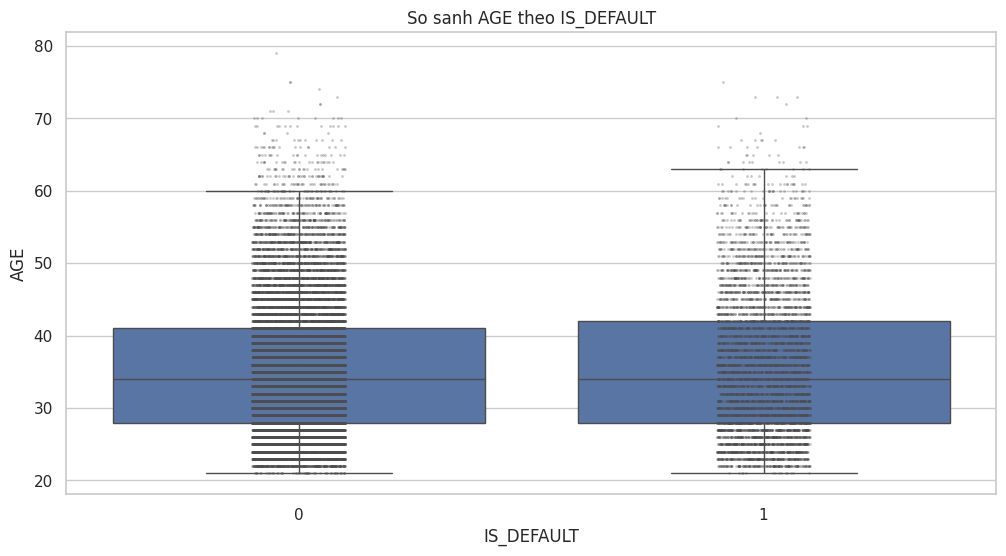

In [5]:
#Biểu đồ hộp giữa tuổi và tình trạng nợ xấu
vsl.box_group(df= df, x= 'IS_DEFAULT', y= 'AGE')

/home/tbm-demi/Documents/Code/Finance/src/visualization.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation= rotation)
2026-04-03 15:30:28 - INFO - Generated Distribution plot for: AGE


<Axes: title={'center': 'Distribution of AGE'}, xlabel='Age', ylabel='Frequency'>

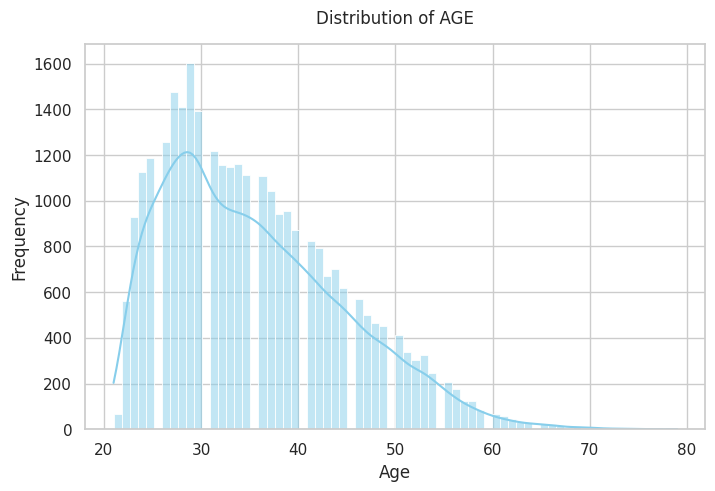

In [6]:
#Phân bố tuổi khách hàng và tình trạng nợ xấu
vsl.plot_distribution(df= df, column= 'AGE')

                  ID  LIMIT_BAL       SEX  EDUCATION  MARRIAGE       AGE  \
ID          1.000000   0.026179  0.018497   0.037074 -0.028208  0.018678   
LIMIT_BAL   0.026179   1.000000  0.024755  -0.232171 -0.111012  0.144713   
SEX         0.018497   0.024755  1.000000   0.014533 -0.028522 -0.090874   
EDUCATION   0.037074  -0.232171  0.014533   1.000000 -0.137626  0.181614   
MARRIAGE   -0.028208  -0.111012 -0.028522  -0.137626  1.000000 -0.412001   
AGE         0.018678   0.144713 -0.090874   0.181614 -0.412001  1.000000   
PAY_1      -0.030575  -0.271214 -0.057643   0.113732  0.018557 -0.039447   
PAY_2      -0.011215  -0.296382 -0.070771   0.131588  0.023620 -0.050148   
PAY_3      -0.018494  -0.286123 -0.066096   0.124089  0.032399 -0.053048   
PAY_4      -0.002735  -0.267460 -0.060173   0.117959  0.031831 -0.049722   
PAY_5      -0.022199  -0.249411 -0.055064   0.105927  0.034377 -0.053826   
PAY_6      -0.020270  -0.235195 -0.044008   0.091359  0.033168 -0.048773   
BILL_AMT1   

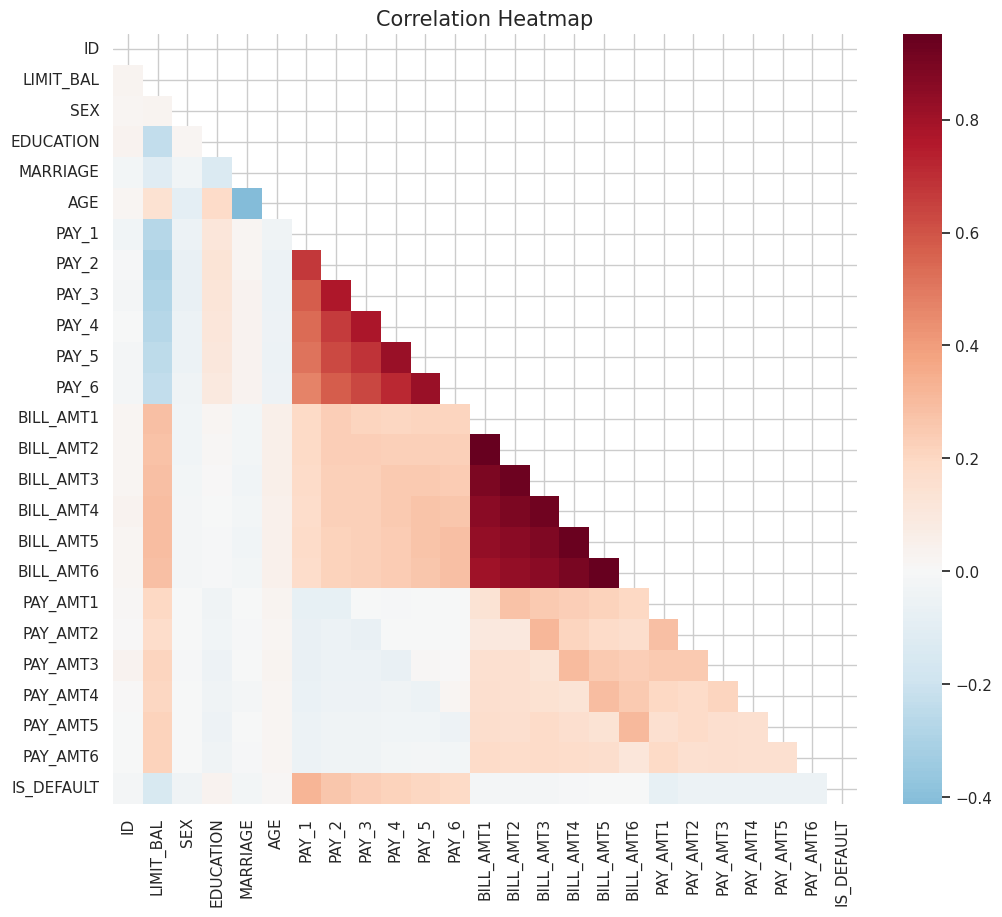

In [7]:
# Heatmap cho payment status: PAY_X
corr = df_raw.corr()

print(corr)

vsl.plot_correlation_matrix(df= df_raw)